Cell 1 — Packages

In [2]:
# ============================================================
# Packages
# ============================================================

import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import qmc
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

from model_registry import get_model

Cell 2 — Load config

In [4]:
# ============================================================
# Load config
# ============================================================

CONFIG_FILE = "configs/global_fit_model2.json"

config = json.load(open(CONFIG_FILE))

RUN_NAME = config["run_name"]
MODEL_NAME = config["model_name"]

model = get_model(MODEL_NAME)

EXCEL_FILE = config["excel_file"]
EXCEL_SHEET = config["excel_sheet"]

RESULTS_DIR = Path(config["results_dir"])
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

N_STARTS = int(config["n_starts"])
RANDOM_SEED = int(config["random_seed"])

SCALE = float(config.get("scale", 500.0))

SHARED_PARAMS = config["shared_params"]
LOCAL_KTXN_PARAMS = config["local_ktxn_params"]

FIT_PARAMS = SHARED_PARAMS + list(LOCAL_KTXN_PARAMS.values())

guess = {p: float(v) for p, v in config["guess"].items()}
lower = {p: float(v[0]) for p, v in config["bounds"].items()}
upper = {p: float(v[1]) for p, v in config["bounds"].items()}

print("RUN SUMMARY")
print("=" * 70)
print("Run name:", RUN_NAME)
print("Model:", MODEL_NAME)
print("Excel:", EXCEL_FILE)
print("Sheet:", EXCEL_SHEET)
print("Fit parameters:", FIT_PARAMS)

RUN SUMMARY
Run name: global_fit_model2_dataset_specific_ktxn
Model: model2_inactivegate_fuel
Excel: data/in_vitro_ctRSD_modeling_data.xls
Sheet: All Data
Fit parameters: ['ksd', 'kfsd', 'krev', 'kf_rep', 'kRz', 'kfld', 'klk', 'basal_frac', 'k_txn_Fig2D', 'k_txn_Fig6C', 'k_txn_Fig4H']


Cell 3 — Load data

In [5]:
# ============================================================
# Load experimental data
# ============================================================

df = pd.read_excel(
    EXCEL_FILE,
    sheet_name=EXCEL_SHEET,
    header=None
)

Cell 4 — Dataset definitions

In [6]:
# ============================================================
# Dataset definitions
# ============================================================

datasets = [
    {
        "name": "Fig2D",
        "ktxn_param": "k_txn_Fig2D",
        "conditions": [
            {"name": "fig2d_50nM_I0",   "col": 1, "label": "50 nM I0",   "RSD": 50.0, "IN": 0.0,  "F": 0.0},
            {"name": "fig2d_50nM_I1",   "col": 2, "label": "50 nM I1",   "RSD": 50.0, "IN": 50.0, "F": 0.0},
            {"name": "fig2d_25nM_I1",   "col": 3, "label": "25 nM I1",   "RSD": 25.0, "IN": 25.0, "F": 0.0},
            {"name": "fig2d_12p5nM_I1", "col": 4, "label": "12.5 nM I1", "RSD": 12.5, "IN": 12.5, "F": 0.0},
            {"name": "fig2d_6p25nM_I1", "col": 5, "label": "6.25 nM I1", "RSD": 6.25, "IN": 6.25, "F": 0.0},
            {"name": "fig2d_2p5nM_I1",  "col": 6, "label": "2.5 nM I1",  "RSD": 2.5,  "IN": 2.5,  "F": 0.0},
        ],
    },
    {
        "name": "Fig6C",
        "ktxn_param": "k_txn_Fig6C",
        "conditions": [
            {"name": "fig6c_10G1_I0", "col": 7,  "label": "10 G1, I0", "RSD": 10.0, "IN": 0.0,  "F": 0.0},
            {"name": "fig6c_25G1_I0", "col": 8,  "label": "25 G1, I0", "RSD": 25.0, "IN": 0.0,  "F": 0.0},
            {"name": "fig6c_50G1_I0", "col": 9,  "label": "50 G1, I0", "RSD": 50.0, "IN": 0.0,  "F": 0.0},
            {"name": "fig6c_10G1_I1", "col": 10, "label": "10 G1, I1", "RSD": 10.0, "IN": 50.0, "F": 0.0},
            {"name": "fig6c_25G1_I1", "col": 11, "label": "25 G1, I1", "RSD": 25.0, "IN": 50.0, "F": 0.0},
            {"name": "fig6c_50G1_I1", "col": 12, "label": "50 G1, I1", "RSD": 50.0, "IN": 50.0, "F": 0.0},
        ],
    },
    {
        "name": "Fig4H",
        "ktxn_param": "k_txn_Fig4H",
        "conditions": [
            {"name": "fig4h_0in_0fuel",     "col": 13, "label": "I0",                   "RSD": 25.0, "IN": 0.0,  "F": 0.0},
            {"name": "fig4h_1p25in_0fuel",  "col": 14, "label": "1.25 nM I1",           "RSD": 25.0, "IN": 1.25, "F": 0.0},
            {"name": "fig4h_2p5in_0fuel",   "col": 15, "label": "2.5 nM I1",            "RSD": 25.0, "IN": 2.5,  "F": 0.0},
            {"name": "fig4h_0in_25fuel",    "col": 16, "label": "25 nM F1",             "RSD": 25.0, "IN": 0.0,  "F": 25.0},
            {"name": "fig4h_1p25in_25fuel", "col": 17, "label": "1.25 nM I1, 25 nM F1", "RSD": 25.0, "IN": 1.25, "F": 25.0},
            {"name": "fig4h_2p5in_25fuel",  "col": 18, "label": "2.5 nM I1, 25 nM F1",  "RSD": 25.0, "IN": 2.5,  "F": 25.0},
        ],
    },
]

Cell 5 — Preprocessing functions

In [7]:
# ============================================================
# Read one experimental trajectory
# ============================================================

def read_condition(condition, start_row=3):

    t = []
    x = []

    for r in range(start_row, len(df)):

        time_val = df.iloc[r, 0]
        signal_val = df.iloc[r, condition["col"]]

        if pd.isna(time_val) or pd.isna(signal_val):
            break

        t.append(float(time_val))
        x.append(float(signal_val))

    t = np.array(t, dtype=float)
    x = np.array(x, dtype=float) * SCALE

    return t, x


# ============================================================
# Automatic cutoff function to separate transient and plateau
# ============================================================

def estimate_cutoff_index(t, x, frac=0.98, hold_points=20, drift_tol=0.03):

    tail = x[int(0.9 * len(x)):]
    final_level = np.mean(tail)

    if final_level <= 0:
        return len(x)

    tail_drift = (tail[-1] - tail[0]) / final_level

    if abs(tail_drift) > drift_tol:
        return len(x)

    threshold = frac * final_level

    for i in range(len(x) - hold_points):

        if np.all(x[i:i + hold_points] >= threshold):
            return i

    return len(x)


# ============================================================
# Estimate effective reporter concentration
# ============================================================

def estimate_reporter_total(x_full, x_plateau):

    if len(x_plateau) > 0:
        return float(np.mean(x_plateau))

    return float(x_full[-1])


# ============================================================
# Build one processed condition
# ============================================================

def build_condition(condition):

    t_full, x_full = read_condition(condition)

    row_end = estimate_cutoff_index(t_full, x_full)

    condition["t_full"] = t_full
    condition["x_full"] = x_full

    condition["t_exp"] = t_full[:row_end]
    condition["x_exp"] = x_full[:row_end]

    condition["t_plateau"] = t_full[row_end:]
    condition["x_plateau"] = x_full[row_end:]

    condition["DRL0"] = estimate_reporter_total(
        x_full,
        condition["x_plateau"]
    )

    condition["row_end"] = int(row_end)

    return condition

Cell 6 — Build datasets

In [8]:
# ============================================================
# Build all processed datasets
# ============================================================

for dataset in datasets:

    for condition in dataset["conditions"]:

        build_condition(condition)


# ============================================================
# Dataset summary
# ============================================================

print("\nDATASET SUMMARY")
print("=" * 70)

for dataset in datasets:

    print(f"\n{dataset['name']}")

    for condition in dataset["conditions"]:

        print(
            f"{condition['name']:<24} | "
            f"fit points = {len(condition['t_exp']):<5} | "
            f"plateau points = {len(condition['t_plateau']):<5} | "
            f"IN = {condition['IN']:<6} | "
            f"Fuel = {condition['F']:<6} | "
            f"Gate = {condition['RSD']:<6} | "
            f"DRL0 = {condition['DRL0']:.2f} nM"
        )


DATASET SUMMARY

Fig2D
fig2d_50nM_I0            | fit points = 451   | plateau points = 0     | IN = 0.0    | Fuel = 0.0    | Gate = 50.0   | DRL0 = 161.40 nM
fig2d_50nM_I1            | fit points = 301   | plateau points = 150   | IN = 50.0   | Fuel = 0.0    | Gate = 50.0   | DRL0 = 490.61 nM
fig2d_25nM_I1            | fit points = 302   | plateau points = 149   | IN = 25.0   | Fuel = 0.0    | Gate = 25.0   | DRL0 = 491.89 nM
fig2d_12p5nM_I1          | fit points = 311   | plateau points = 140   | IN = 12.5   | Fuel = 0.0    | Gate = 12.5   | DRL0 = 489.62 nM
fig2d_6p25nM_I1          | fit points = 348   | plateau points = 101   | IN = 6.25   | Fuel = 0.0    | Gate = 6.25   | DRL0 = 490.61 nM
fig2d_2p5nM_I1           | fit points = 385   | plateau points = 64    | IN = 2.5    | Fuel = 0.0    | Gate = 2.5    | DRL0 = 491.54 nM

Fig6C
fig6c_10G1_I0            | fit points = 203   | plateau points = 0     | IN = 0.0    | Fuel = 0.0    | Gate = 10.0   | DRL0 = 79.71 nM
fig6c_25G1_I0     

Cell 7 — Model prediction and residuals

In [9]:
# ============================================================
# Build parameter dictionary for one dataset
# ============================================================

def unpack_params(log_params, dataset):

    values = 10 ** np.asarray(log_params)

    fit_dict = dict(zip(FIT_PARAMS, values))

    params = {}

    for p in SHARED_PARAMS:
        params[p] = fit_dict[p]

    params["k_txn"] = fit_dict[dataset["ktxn_param"]]

    return params


# ============================================================
# Prediction function
# ============================================================

def predict(condition, params):

    t_eval_min = condition["t_exp"]
    t_eval_sec = np.asarray(t_eval_min, dtype=float) * 60.0

    sol = solve_ivp(
        lambda t, y: model.rhs(
            t,
            y,
            RSD_temp=condition["RSD"],
            IN_temp=condition["IN"],
            F_temp=condition["F"],
            params=params,
        ),
        (t_eval_sec[0], t_eval_sec[-1]),
        model.initial_conditions(condition, params),
        t_eval=t_eval_sec,
        method="LSODA",
        rtol=1e-6,
        atol=1e-6,
    )

    if (not sol.success) or np.any(~np.isfinite(sol.y)):
        return np.full_like(t_eval_min, 1e9, dtype=float)

    return sol.y[model.output_index]


# ============================================================
# Normalized residual for one condition
# ============================================================

def compute_normalized_residual(condition, params):

    x_model = predict(condition, params)

    res = x_model - condition["x_exp"]

    scale = np.max(condition["x_exp"])

    if scale <= 0:
        scale = 1.0

    points = len(condition["x_exp"])

    return res / scale / np.sqrt(points)


# ============================================================
# Residual function used by least_squares
# ============================================================

def residuals(log_params):

    residual_list = []

    for dataset in datasets:

        params = unpack_params(log_params, dataset)

        for condition in dataset["conditions"]:

            residual_list.append(
                compute_normalized_residual(condition, params)
            )

    return np.concatenate(residual_list)

Cell 8 — Sobol fit

In [11]:
# ============================================================
# Fit parameters using Sobol multi-start
# ============================================================

lower_bounds = np.array([
    np.log10(lower[p])
    for p in FIT_PARAMS
])

upper_bounds = np.array([
    np.log10(upper[p])
    for p in FIT_PARAMS
])

N_STARTS_REQUESTED = N_STARTS

m = int(np.ceil(np.log2(N_STARTS_REQUESTED)))
N_STARTS = 2 ** m

print(
    f"\nRequested {N_STARTS_REQUESTED} optimization starts."
    f"\nUsing {N_STARTS} Sobol starts.\n"
)

sampler = qmc.Sobol(
    d=len(FIT_PARAMS),
    scramble=True,
    seed=RANDOM_SEED,
)

U = sampler.random_base2(m=m)

x0_all = lower_bounds + U * (upper_bounds - lower_bounds)

best = None

for i, x0 in enumerate(x0_all):

    result = least_squares(
        residuals,
        x0,
        bounds=(lower_bounds, upper_bounds),
        method="trf",
        max_nfev=3000,
    )

    print(f"Run {i + 1}/{N_STARTS} | cost = {result.cost:.4e}")

    if best is None or result.cost < best.cost:
        best = result


best_x = best.x
best_cost = best.cost
best_sse = 2 * best_cost

best_fit_params = dict(zip(FIT_PARAMS, 10 ** best_x))

print("\nBest-fit parameters:")
for p, v in best_fit_params.items():
    print(f"{p:<20} = {v:.8e}")

print(f"\nBest cost (0.5 * SSE) = {best_cost:.8e}")
print(f"Best SSE              = {best_sse:.8e}")


Requested 64 optimization starts.
Using 64 Sobol starts.

Run 1/64 | cost = 7.3678e-01
Run 2/64 | cost = 1.6276e-01
Run 3/64 | cost = 1.8418e-01
Run 4/64 | cost = 1.7232e-01
Run 5/64 | cost = 2.1177e-01
Run 6/64 | cost = 1.2151e+00
Run 7/64 | cost = 2.9529e-01
Run 8/64 | cost = 3.1065e-01
Run 9/64 | cost = 1.7110e-01
Run 10/64 | cost = 1.2567e+00
Run 11/64 | cost = 1.1891e+00
Run 12/64 | cost = 6.4910e-01
Run 13/64 | cost = 1.6168e-01
Run 14/64 | cost = 2.0538e-01
Run 15/64 | cost = 2.0315e-01
Run 16/64 | cost = 2.0726e-01
Run 17/64 | cost = 1.8993e-01
Run 18/64 | cost = 1.3328e+00
Run 19/64 | cost = 2.5166e-01
Run 20/64 | cost = 1.7654e-01
Run 21/64 | cost = 1.6188e-01
Run 22/64 | cost = 1.5290e-01
Run 23/64 | cost = 1.9420e-01
Run 24/64 | cost = 1.6361e-01
Run 25/64 | cost = 2.3659e-01
Run 26/64 | cost = 7.1217e-01
Run 27/64 | cost = 1.8155e-01
Run 28/64 | cost = 5.9458e-01
Run 29/64 | cost = 2.1866e-01
Run 30/64 | cost = 2.0653e-01
Run 31/64 | cost = 2.6272e-01
Run 32/64 | cost = 1

Cell 9 — Save parameter CSV

In [12]:
# ============================================================
# Save parameter table
# ============================================================

param_df = pd.DataFrame({
    "parameter": list(best_fit_params.keys()),
    "value": list(best_fit_params.values()),
    "log10_value": np.log10(list(best_fit_params.values())),
})

param_df.to_csv(
    RESULTS_DIR / "fit_parameters.csv",
    index=False,
)

param_df

,parameter,value,log10_value
0,ksd,1.337306e-04,-3.873769
1,kfsd,5.804830e-05,-4.236211
2,krev,3.271504e-06,-5.485253
3,kf_rep,9.128633e-07,-6.039594
4,kRz,1.979268e-03,-2.703495
5,kfld,1.767808e-02,-1.752565
6,klk,5.730299e-07,-6.241823
7,basal_frac,1.584408e-01,-0.800133
8,k_txn_Fig2D,2.027066e-02,-1.693132
9,k_txn_Fig6C,3.762450e-02,-1.424529


Cell 10 — Plot fits

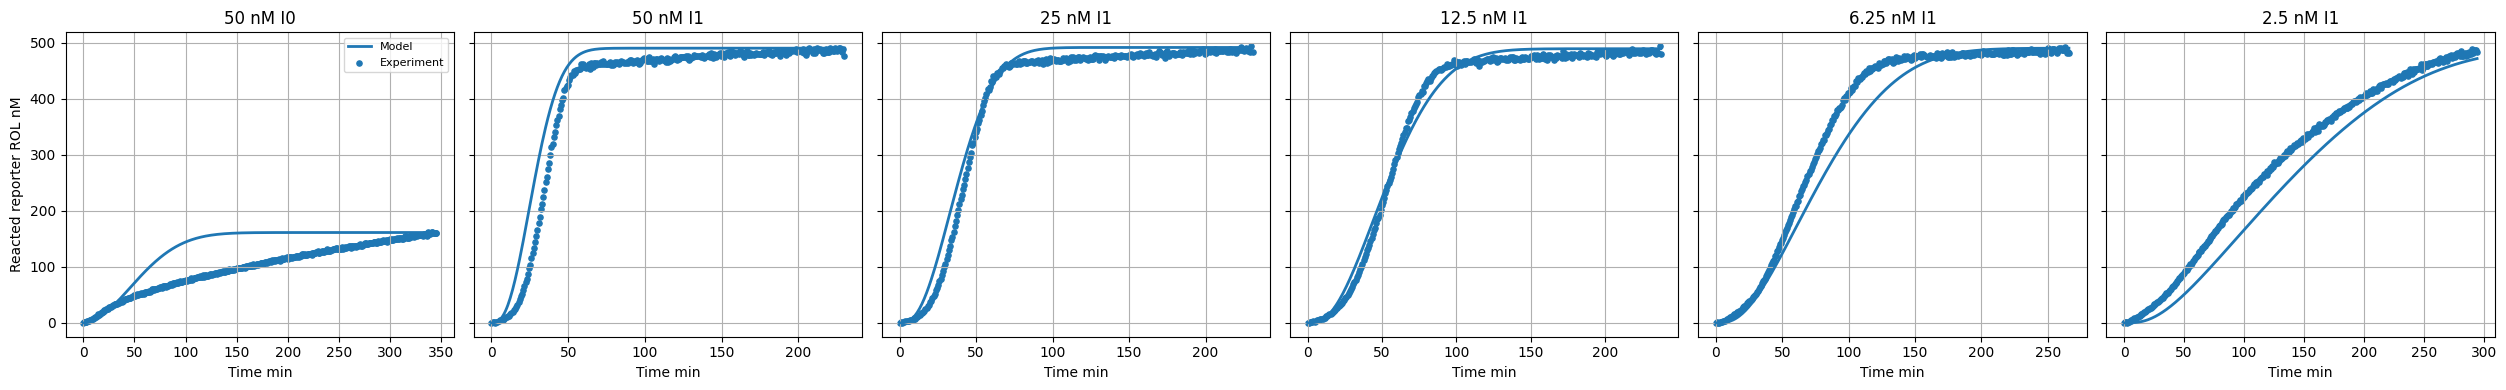

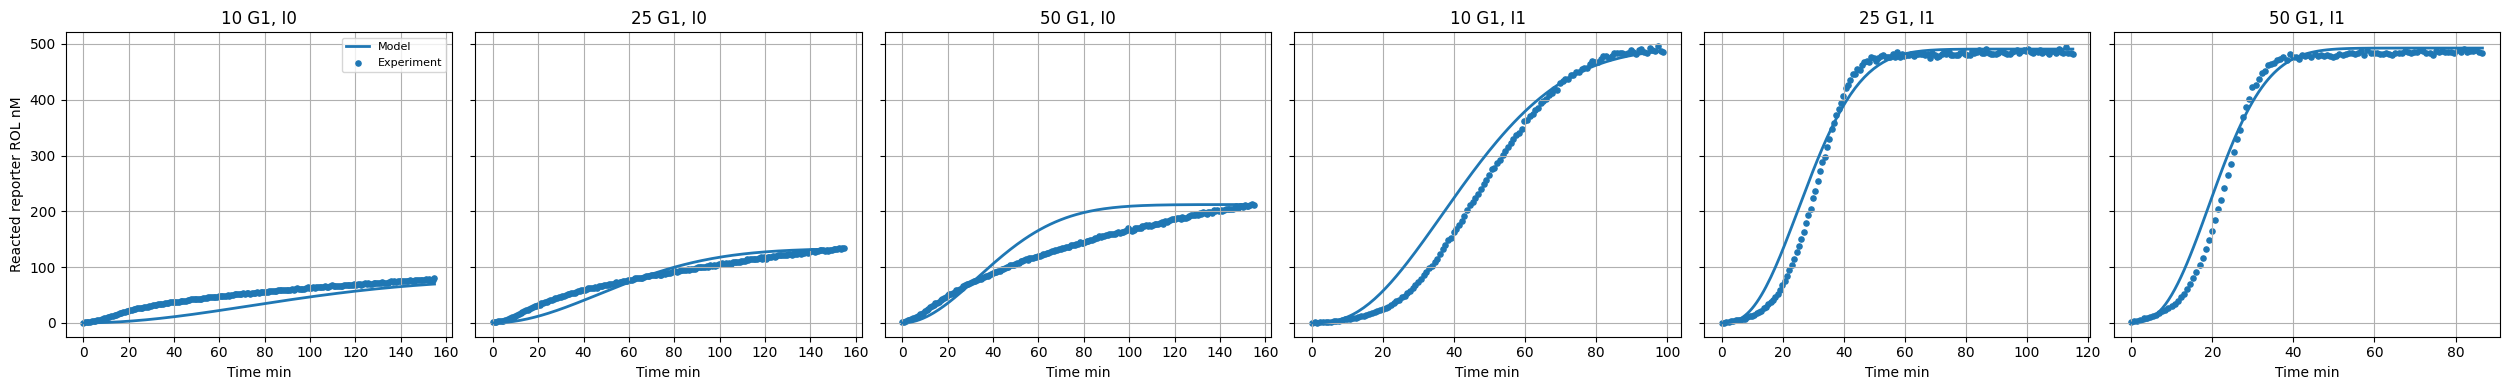

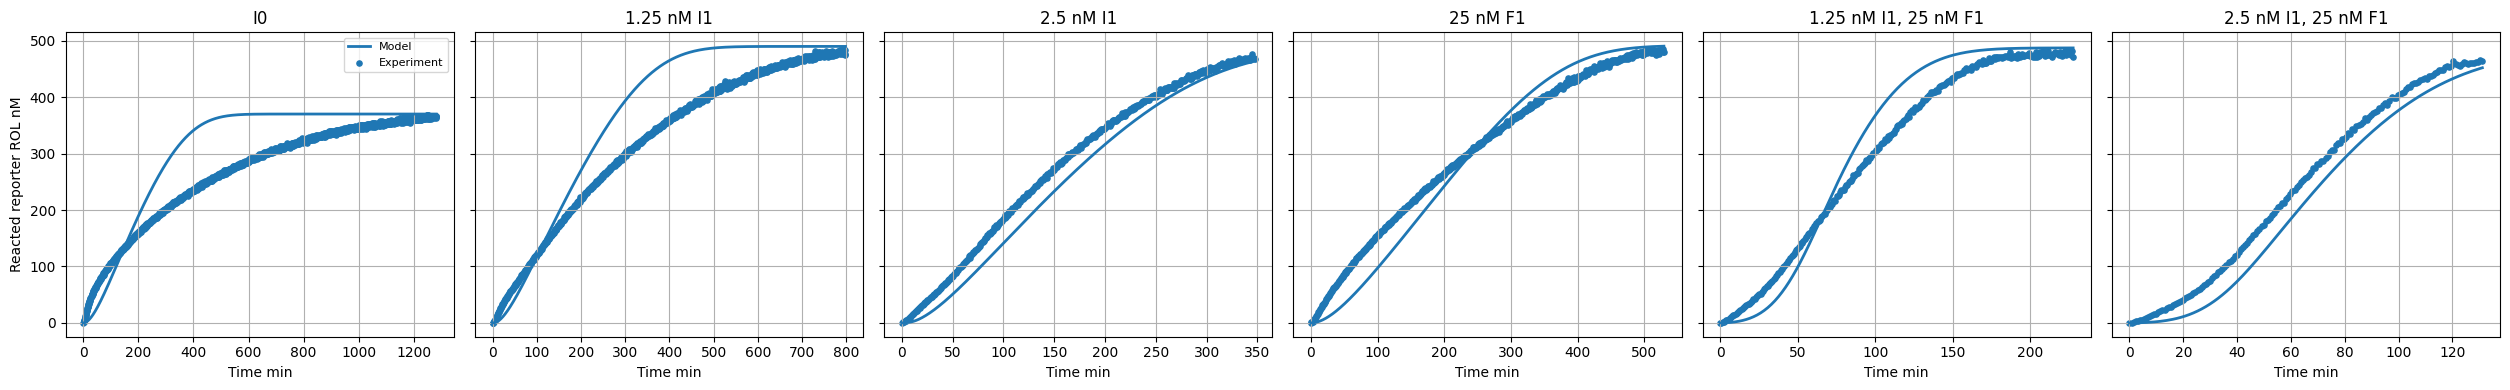

In [14]:
# ============================================================
# Plot fitted timecourses
# ============================================================

for dataset in datasets:

    params = unpack_params(best_x, dataset)

    fig, axes = plt.subplots(
        1,
        len(dataset["conditions"]),
        figsize=(4.2 * len(dataset["conditions"]), 4),
        sharey=True,
    )

    axes = np.array(axes).reshape(-1)

    for ax, condition in zip(axes, dataset["conditions"]):

        x_model = predict(condition, params)

        ax.plot(
            condition["t_exp"],
            x_model,
            linewidth=2,
            label="Model",
        )

        ax.scatter(
            condition["t_exp"],
            condition["x_exp"],
            s=14,
            label="Experiment",
        )

        ax.set_title(condition["label"])
        ax.set_xlabel("Time min")
        ax.grid(True)

    axes[0].set_ylabel("Reacted reporter ROL nM")
    axes[0].legend(fontsize=8)

    plt.tight_layout()

    fig.savefig(
        RESULTS_DIR / f"{RUN_NAME}_{dataset['name']}_fit_timecourses.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

Cell 11 — Cost landscapes

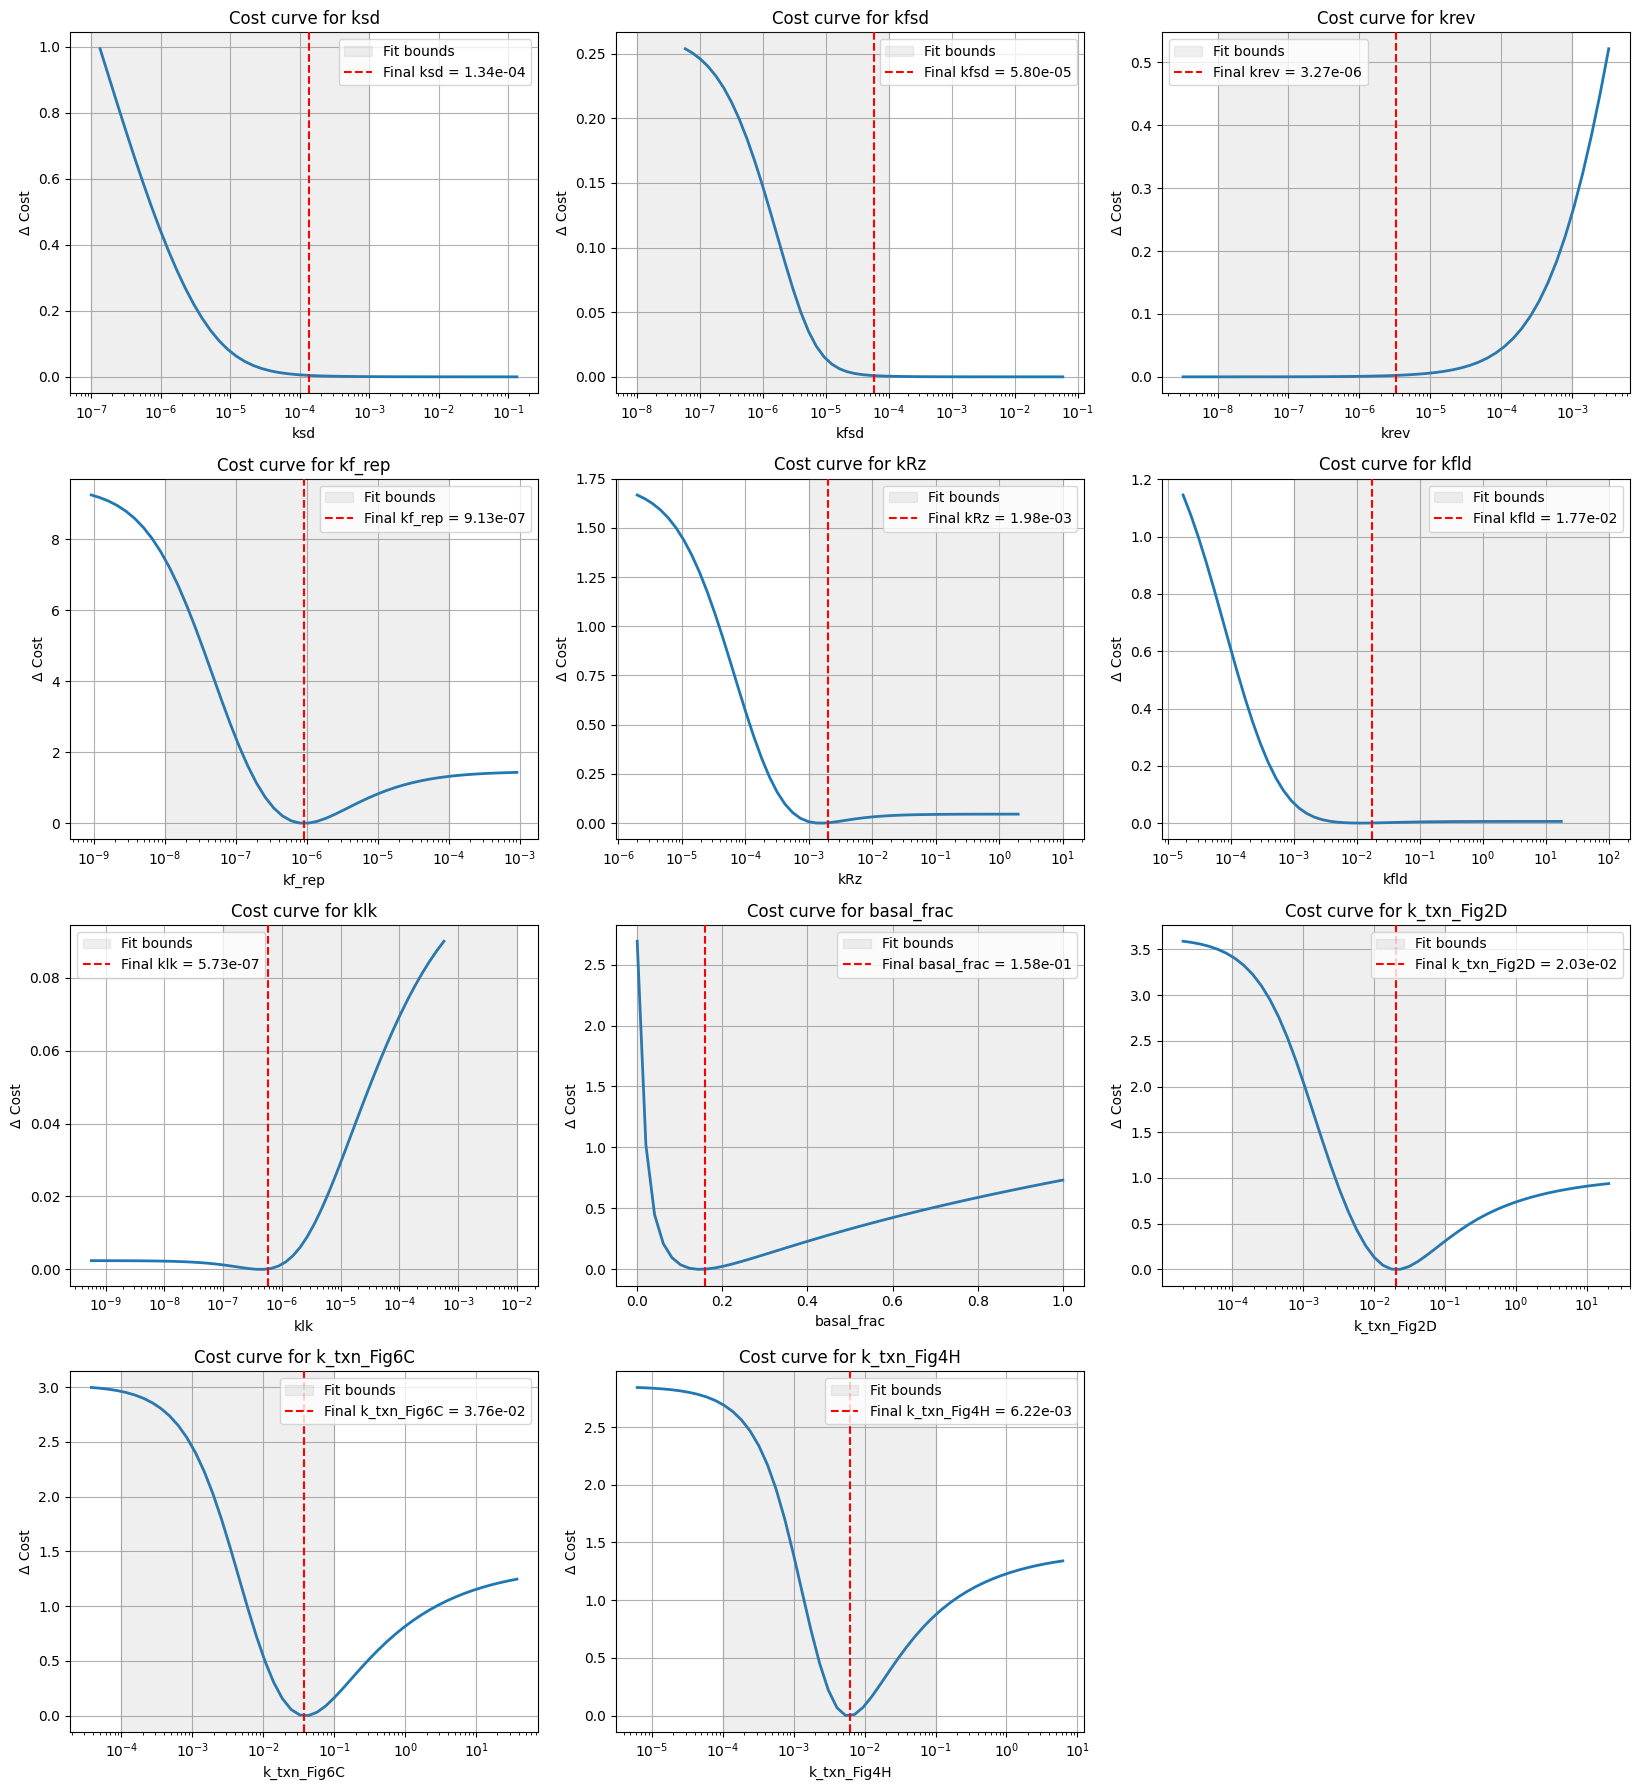

In [15]:
# ============================================================
# Cost landscapes for fitted parameters
# ============================================================

SCAN_PARAMS = FIT_PARAMS.copy()

SCAN_HALF_WIDTH_LOG10 = 3.0
N_SCAN = 50

LINEAR_SCAN_RANGES = {
    "basal_frac": (0, 1),
}

max_cols = 3

n_params = len(SCAN_PARAMS)
ncols = min(max_cols, n_params)
nrows = int(np.ceil(n_params / max_cols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5.5 * ncols, 4.5 * nrows),
)

axes = np.array(axes).reshape(-1)

for ax, p in zip(axes, SCAN_PARAMS):

    center_val = best_fit_params[p]
    center_log10 = np.log10(center_val)

    if p in LINEAR_SCAN_RANGES:

        scan_lower, scan_upper = LINEAR_SCAN_RANGES[p]
        param_vals = np.linspace(scan_lower, scan_upper, N_SCAN)
        param_vals = np.maximum(param_vals, 1e-12)

    else:

        param_vals = np.logspace(
            center_log10 - SCAN_HALF_WIDTH_LOG10,
            center_log10 + SCAN_HALF_WIDTH_LOG10,
            N_SCAN,
        )

    cost_vals = []

    for p_test in param_vals:

        params_test = best_fit_params.copy()
        params_test[p] = p_test

        log_test = np.array([
            np.log10(params_test[q])
            for q in FIT_PARAMS
        ])

        try:
            res_all = residuals(log_test)
            cost = np.sum(res_all ** 2)

            if not np.isfinite(cost):
                cost = np.nan

        except Exception:
            cost = np.nan

        cost_vals.append(cost)

    cost_vals = np.array(cost_vals, dtype=float)
    delta_cost = cost_vals - np.nanmin(cost_vals)

    if p in LINEAR_SCAN_RANGES:
        ax.plot(param_vals, delta_cost, linewidth=2)
    else:
        ax.semilogx(param_vals, delta_cost, linewidth=2)

    ax.axvspan(
        lower[p],
        upper[p],
        alpha=0.12,
        color="gray",
        label="Fit bounds",
        zorder=3,
    )

    ax.axvline(
        best_fit_params[p],
        linestyle="--",
        linewidth=1.5,
        color="red",
        label=f"Final {p} = {best_fit_params[p]:.2e}",
        zorder=4,
    )

    ax.set_xlabel(p)
    ax.set_ylabel("Δ Cost")
    ax.set_title(f"Cost curve for {p}")
    ax.grid(True)
    ax.legend()

for ax in axes[n_params:]:
    ax.axis("off")

plt.tight_layout()

fig.savefig(
    RESULTS_DIR / f"{RUN_NAME}_cost_landscapes.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

Cell 12 — Boundary check

In [16]:
# ============================================================
# Boundary proximity check
# ============================================================

print("\nBoundary proximity check:")
print("-" * 70)

BOUNDARY_TOL = 0.05

LINEAR_BOUNDARY_PARAMS = [
    "basal_frac",
]

boundary_check = []

for i, p in enumerate(FIT_PARAMS):

    if p in LINEAR_BOUNDARY_PARAMS:

        value = best_fit_params[p]
        lower_val = lower[p]
        upper_val = upper[p]

        parameter_range = upper_val - lower_val

        dist_to_lower = (value - lower_val) / parameter_range
        dist_to_upper = (upper_val - value) / parameter_range

    else:

        log_val = best_x[i]
        log_lower = lower_bounds[i]
        log_upper = upper_bounds[i]

        parameter_range = log_upper - log_lower

        dist_to_lower = (log_val - log_lower) / parameter_range
        dist_to_upper = (log_upper - log_val) / parameter_range

        value = 10 ** log_val
        lower_val = 10 ** log_lower
        upper_val = 10 ** log_upper

    if dist_to_lower < BOUNDARY_TOL:
        status = "near lower bound"

    elif dist_to_upper < BOUNDARY_TOL:
        status = "near upper bound"

    else:
        status = "not within 5% of bound"

    boundary_check.append({
        "parameter": p,
        "value": value,
        "lower": lower_val,
        "upper": upper_val,
        "dist_to_lower": dist_to_lower,
        "dist_to_upper": dist_to_upper,
        "status": status,
    })

    print(
        f"{p:<20} | "
        f"value = {value:.4e} | "
        f"lower = {lower_val:.4e} | "
        f"upper = {upper_val:.4e} | "
        f"{status}"
    )


Boundary proximity check:
----------------------------------------------------------------------
ksd                  | value = 1.3373e-04 | lower = 1.0000e-07 | upper = 1.0000e-03 | not within 5% of bound
kfsd                 | value = 5.8048e-05 | lower = 1.0000e-08 | upper = 1.0000e-04 | not within 5% of bound
krev                 | value = 3.2715e-06 | lower = 1.0000e-08 | upper = 1.0000e-03 | not within 5% of bound
kf_rep               | value = 9.1286e-07 | lower = 1.0000e-08 | upper = 1.0000e-04 | not within 5% of bound
kRz                  | value = 1.9793e-03 | lower = 1.0000e-03 | upper = 1.0000e+01 | not within 5% of bound
kfld                 | value = 1.7678e-02 | lower = 1.0000e-03 | upper = 1.0000e+02 | not within 5% of bound
klk                  | value = 5.7303e-07 | lower = 1.0000e-07 | upper = 1.0000e-02 | not within 5% of bound
basal_frac           | value = 1.5844e-01 | lower = 1.0000e-04 | upper = 1.0000e+00 | not within 5% of bound
k_txn_Fig2D          | value =